In [ ]:
from langchain_core.output_parsers import JsonOutputParser
import os
import kagglehub
import pandas as pd
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain_core.runnables import RunnablePassthrough
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader

# Global variables
retriever = None
mcq_chain = None
question_count = 5

# Function to load PDF and create vectorstore
def create_vectorstore_from_pdf(pdf_path):
    # Load PDF
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    
    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    splits = text_splitter.split_documents(docs)
    
    # Initialize HuggingFace embeddings
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    
    # Create FAISS vectorstore
    vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)
    return vectorstore

# Define state structure for the LangGraph
class GraphState(TypedDict):
    question: str
    context: Optional[List[Document]]
    answer: Optional[str]

# Function to retrieve context
def retrieve_context(state: GraphState) -> GraphState:
    question = state["question"]
    context = retriever.get_relevant_documents(question)
    return {"question": question, "context": context}

# Function to generate MCQs
def generate_mcqs(state: GraphState) -> GraphState:
    question = state["question"]
    context = state["context"]
    
    result = mcq_chain.invoke({
        "input": question,
        "context": context,
        "num_questions": question_count
    })
    
    return {"question": question, "context": context, "answer": result}

# Function to set up the MCQ generation pipeline
def setup_mcq_generator(pdf_path, num_questions=5, api_key=None):
    # Set API key if provided
    if api_key:
        os.environ["GROQ_API_KEY"] = api_key
    
    # Set question count in global variable
    global question_count
    question_count = num_questions
    
    # Initialize Groq LLM with Qwen model
    llm = ChatGroq(
        model="qwen-2.5-32b",
        api_key="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"
    )
    
    # Create vectorstore and retriever
    vectorstore = create_vectorstore_from_pdf(pdf_path)
    global retriever
    retriever = vectorstore.as_retriever()
    
    # Create MCQ generation prompt
    # system_template = """
    # You are an expert at creating multiple-choice questions based on educational content.
    # Use the following pieces of retrieved context to create {num_questions} high-quality multiple-choice questions.
    # For each question, provide 4 options (A, B, C, D) with exactly one correct answer.
    # After listing all questions and options, provide an answer key.
    # Ensure questions test understanding rather than just recall.
    
    # Retrieved context:
    # {context}
    # """
    system_template = """
    You are an expert in designing educational multiple-choice questions that assess deep understanding and critical thinking. Using the retrieved context provided below, generate {num_questions} high-quality, challenging multiple-choice questions that cover a range of topics within the material.

    For each question, please ensure that:
    • The question prompt is clear, concise, and tests conceptual understanding rather than simple memorization.
    • There are exactly four answer options labeled A, B, C, and D.
    • Only one option is correct, while the remaining three are plausible distractors that reflect common misconceptions or errors.
    • Each question is uniquely phrased to cover different aspects or details of the content.

    After presenting all the questions with their corresponding options, include a detailed answer key that clearly indicates the correct answer for each question.

    Retrieved context:
    {context}
    """
    
    human_template = "Create {num_questions} multiple-choice questions from this content."
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_template),
        ("human", human_template)
    ])
    
    # Create chain for MCQ generation
    global mcq_chain
    mcq_chain = prompt | llm
    
    # Create the graph
    workflow = StateGraph(GraphState)
    
    # Add nodes
    workflow.add_node("retrieve", retrieve_context)
    workflow.add_node("generate", generate_mcqs)
    
    # Add edges
    workflow.add_edge(START, "retrieve")
    workflow.add_edge("retrieve", "generate")
    workflow.add_edge("generate", END)
    
    # Compile the graph
    app = workflow.compile()
    
    return app

# Function to run MCQ generation
def run_mcq_generator(app, question="Generate multiple-choice questions from this document"):
    result = app.invoke({
        "question": question
    })
    return result["answer"]

# Example usage
if __name__ == "__main__":
    pdf_path =  r"C:\Users\Sumit\Downloads\attention.pdf"  # Replace with your PDF file path
    app = setup_mcq_generator(pdf_path, num_questions=10)
    mcqs = run_mcq_generator(app)
    print(mcqs)

In [102]:
mcqs

{'questions': [{'question': 'Which paper introduced a decomposable attention model for textual entailment and sentence representations?',
   'options': {'A': '[26] McClosky et al.',
    'B': '[27] Parikh et al.',
    'C': '[28] Paulus et al.',
    'D': '[29] Petrov et al.'},
   'correct_answer': 'B',
   'explanation': 'The paper by Parikh et al. [27] introduced a decomposable attention model.'},
  {'question': 'Which model architecture relies entirely on self-attention, avoiding sequence-aligned RNNs and convolutions?',
   'options': {'A': 'Transformer',
    'B': 'Recurrent Neural Network (RNN)',
    'C': 'Convolutional Neural Network (CNN)',
    'D': 'Memory Networks'},
   'correct_answer': 'A',
   'explanation': 'The Transformer model relies entirely on self-attention.'},
  {'question': 'What is the advantage of the Transformer model over models like [17, 18] and [9]?',
   'options': {'A': 'Faster training',
    'B': 'Reduced number of operations for distant dependencies',
    'C': '

In [131]:
import os
import pandas as pd
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain_core.runnables import RunnablePassthrough
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional, Dict, Literal
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader

# Global variables
retriever = None
mcq_chain = None
question_count = 150

# Function to load PDF and create vectorstore
def create_vectorstore_from_pdf(pdf_path):
    # Load PDF
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    
    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    splits = text_splitter.split_documents(docs)
    
    # Initialize HuggingFace embeddings
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    
    # Create FAISS vectorstore
    vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)
    return vectorstore

# Define state structure for the LangGraph
class GraphState(TypedDict):
    question: str
    context: Optional[List[Document]]
    answer: Optional[str]
    batch_num: Optional[int]
    all_questions: Optional[Dict]
    next_node: Optional[str]

# Function to retrieve context
def retrieve_context(state: GraphState) -> GraphState:
    question = state["question"]
    context = retriever.get_relevant_documents(question)
    batch_num = state.get("batch_num", 1)
    all_questions = state.get("all_questions", {})
    
    return {
        "question": question, 
        "context": context, 
        "batch_num": batch_num,
        "all_questions": all_questions,
        "next_node": state.get("next_node")
    }

# Function to generate MCQs with batching approach
def generate_mcqs(state: GraphState) -> GraphState:
    question = state["question"]
    context = state["context"]
    batch_num = state["batch_num"]
    all_questions = state["all_questions"]
    
    # We'll generate in smaller batches to ensure diversity and avoid repetition
    batch_size = 30  # Generate 30 questions per batch
    
    # Invoke the chain and extract the content as string
    response = mcq_chain.invoke({
        "input": question,
        "context": context,
        "num_questions": batch_size,
        "batch_num": batch_num,
        "existing_questions": all_questions
    })
    
    # Handle AIMessage object by extracting the content
    # This handles both string returns and message objects
    if hasattr(response, 'content'):
        result = response.content
    else:
        result = str(response)
    
    # Update all_questions with the new batch
    all_questions[f"batch_{batch_num}"] = result
    
    # Determine if we need more batches
    next_node = "continue" if batch_num * batch_size < question_count else "complete"
    
    # If we're done, compile the final result
    final_answer = None
    if next_node == "complete":
        final_answer = compile_batches(all_questions)
    
    return {
        "question": question, 
        "context": context, 
        "answer": final_answer,
        "batch_num": batch_num + 1,
        "all_questions": all_questions,
        "next_node": next_node
    }

# Router function to determine next step
def router(state: GraphState) -> Literal["continue", "complete"]:
    return state["next_node"]

# Function to compile all batches into a single result
def compile_batches(all_questions):
    final_result = "# 150 Multiple Choice Questions\n\n"
    answer_key = "\n\n# Answer Key\n\n"
    question_num = 1
    
    for batch_key in sorted(all_questions.keys()):
        batch_content = all_questions[batch_key]
        
        # Extract questions and answer key using simple parsing
        lines = batch_content.split('\n')
        
        in_questions = True
        for line in lines:
            if line.strip().lower().startswith("answer key"):
                in_questions = False
                continue
            
            if in_questions:
                # Check if line starts with a question number
                if line.strip() and line[0].isdigit() and '. ' in line[:10]:
                    # Replace the question number with our sequential number
                    parts = line.split('. ', 1)
                    if len(parts) > 1:
                        final_result += f"{question_num}. {parts[1]}\n"
                        question_num += 1
                else:
                    final_result += line + "\n"
            else:
                # In answer key section
                if line.strip() and line[0].isdigit() and '.' in line[:5]:
                    # Extract and update answer key
                    parts = line.split('.', 1)
                    if len(parts) > 1:
                        original_q_num = int(parts[0].strip())
                        # Calculate the adjusted question number
                        batch_index = int(batch_key.split('_')[1]) - 1
                        adjusted_q_num = batch_index * 30 + original_q_num
                        answer_key += f"{adjusted_q_num}.{parts[1]}\n"
    
    return final_result + answer_key

# Function to continue processing
def continue_processing(state: GraphState) -> GraphState:
    # Reset next_node to None to avoid infinite loops
    state["next_node"] = None
    return state

# Function to complete processing
def complete_processing(state: GraphState) -> GraphState:
    return state

# Function to set up the MCQ generation pipeline
def setup_mcq_generator(pdf_path, num_questions=150, api_key=None):
    # Set API key if provided
    if api_key:
        os.environ["GROQ_API_KEY"] = api_key
    
    # Set question count in global variable
    global question_count
    question_count = num_questions
    
    # Initialize Groq LLM with Qwen model
    llm = ChatGroq(
        model="qwen-2.5-32b",
        temperature=0.7,  # Add some randomness to avoid repetitive questions
        api_key="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"
    )
    
    # Create vectorstore and retriever
    vectorstore = create_vectorstore_from_pdf(pdf_path)
    global retriever
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 10}  # Increase retrieval to get more diverse content
    )
    
    # Create MCQ generation prompt with anti-repetition guidance
    system_template = """
    You are an expert in designing educational of ML AI multiple-choice questions that assess deep understanding and critical thinking. Using the retrieved context provided below, generate {num_questions} high-quality, challenging multiple-choice questions that cover a range of topics within the material.

    This is batch #{batch_num} of questions. To avoid repetition with previous batches, focus on different aspects, concepts, or sections of the material than what has been covered before.

    For each question, please ensure that:
    • The question prompt is clear, concise, and tests conceptual understanding rather than simple memorization.
    • There are exactly four answer options labeled A, B, C, and D.
    • Only one option is correct, while the remaining three are plausible distractors that reflect common misconceptions or errors.
    • Each question is uniquely phrased to cover different aspects or details of the content.
    • NO QUESTION SHOULD REPEAT concepts already covered in previous batches.
    • Each question should test a DIFFERENT concept or application.

    After presenting all the questions with their corresponding options, include a detailed answer key that clearly indicates the correct answer for each question.

    Retrieved context:
    {context}
    """
    
    human_template = "This is batch #{batch_num}. Create {num_questions} unique multiple-choice questions from this content that don't overlap with previous batches."
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_template),
        ("human", human_template)
    ])
    
    # Create chain for MCQ generation
    global mcq_chain
    mcq_chain = prompt | llm
    
    # Create the graph
    workflow = StateGraph(GraphState)
    
    # Add nodes
    workflow.add_node("retrieve", retrieve_context)
    workflow.add_node("generate", generate_mcqs)
    workflow.add_node("continue", continue_processing)
    workflow.add_node("complete", complete_processing)
    
    # Define edges with conditional routing
    workflow.add_edge(START, "retrieve")
    workflow.add_edge("retrieve", "generate")
    workflow.add_conditional_edges(
        "generate",
        router,
        {
            "continue": "continue",
            "complete": "complete"
        }
    )
    workflow.add_edge("continue", "retrieve")
    workflow.add_edge("complete", END)
    
    # Compile the graph
    app = workflow.compile()
    
    return app

# Function to run MCQ generator
def run_mcq_generator(app, question="Generate multiple-choice questions from this document"):
    result = app.invoke({
        "question": question,
        "batch_num": 1,
        "all_questions": {},
        "next_node": None
    })
    return result["answer"]

# Example usage
if __name__ == "__main__":
    pdf_path = r"C:\Users\Sumit\Downloads\attention.pdf"  # Replace with your PDF file path
    app = setup_mcq_generator(pdf_path, num_questions=150)
    mcqs = run_mcq_generator(app)
    print(mcqs)

# 150 Multiple Choice Questions

Sure, here are 30 unique multiple-choice questions based on the provided context, focusing on different aspects and avoiding previously covered concepts:

1. **According to the provided context, what is the primary advantage of the Transformer model over previous models?**
   - A) It uses convolutional layers for sequence modeling.
   - B) It relies entirely on self-attention for sequence transduction.
   - C) It uses recurrent neural networks for sequence alignment.
   - D) It employs gated recurrent units to handle long sequences.

2. **What is the main purpose of the Penn Treebank dataset mentioned in the context?**
   - A) To store large collections of annotated text for natural language processing tasks.
   - B) To provide a benchmark for sequence-to-sequence learning.
   - C) To offer a dataset for image recognition tasks.
   - D) To evaluate reinforcement learning algorithms in language modeling.

3. **What does the Scaled Dot-Product Attention m

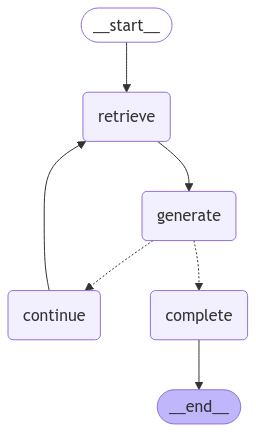

In [136]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
     #This requires some extra dependencies and is optional
    pass

In [7]:
import os
import pandas as pd
import hashlib
import re
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain_core.runnables import RunnablePassthrough
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional, Dict, Literal, Set
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader

# Global variables
retriever = None
mcq_chain = None
question_count = 150
question_tracking = {}  # Track generated questions to avoid repetition

# Function to load PDF and create vectorstore
def create_vectorstore_from_pdf(pdf_path):
    # Load PDF
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    
    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    splits = text_splitter.split_documents(docs)
    
    # Initialize HuggingFace embeddings
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    
    # Create FAISS vectorstore
    vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)
    return vectorstore

# Define state structure for the LangGraph
class GraphState(TypedDict):
    question: str
    context: Optional[List[Document]]
    answer: Optional[str]
    batch_num: Optional[int]
    all_questions: Optional[Dict]
    question_hashes: Optional[Set[str]]
    question_types: Optional[Dict]
    next_node: Optional[str]

# Function to retrieve context with improved diversity
def retrieve_context(state: GraphState) -> GraphState:
    question = state["question"]
    batch_num = state.get("batch_num", 1)
    
    # Modify retrieval strategy based on batch number to get diverse contexts
    k_docs = 10
    if batch_num > 1:
        # Increase diversity for later batches
        k_docs = 10 + (batch_num * 2)  # Retrieve more docs for later batches
    
    context = retriever.get_relevant_documents(question)
    
    # For subsequent batches, try to retrieve different contexts
    if batch_num > 1 and len(context) > k_docs:
        # Skip some of the most relevant docs that were likely used in earlier batches
        start_idx = min((batch_num - 1) * 3, len(context) - k_docs)
        context = context[start_idx:start_idx + k_docs]
    
    return {
        "question": question, 
        "context": context, 
        "batch_num": batch_num,
        "all_questions": state.get("all_questions", {}),
        "question_hashes": state.get("question_hashes", set()),
        "question_types": state.get("question_types", {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0}),
        "next_node": state.get("next_node")
    }

# Helper function to generate a hash for question deduplication
def generate_question_hash(question_text):
    # Normalize text: remove punctuation, lowercase, remove extra spaces
    normalized = re.sub(r'[^\w\s]', '', question_text.lower()).strip()
    normalized = re.sub(r'\s+', ' ', normalized)
    return hashlib.md5(normalized.encode()).hexdigest()

# Function to check question similarity
def is_similar_question(question_text, existing_hashes):
    # Check exact hash match
    question_hash = generate_question_hash(question_text)
    if question_hash in existing_hashes:
        return True
    
    # Additional similarity checks could be implemented here
    # For example, checking for high word overlap or semantic similarity
    
    return False

# Function to extract and classify question type
def classify_question_type(question_text):
    question_lower = question_text.lower()
    
    # Check for paper reference questions
    if "paper" in question_lower or "author" in question_lower or "introduced" in question_lower:
        return "paper_reference"
    
    # Check for application questions
    elif "apply" in question_lower or "using" in question_lower or "implement" in question_lower or "application" in question_lower:
        return "application"
    
    # Check for analysis questions
    elif "analyze" in question_lower or "compare" in question_lower or "evaluate" in question_lower or "why" in question_lower:
        return "analysis"
    
    # Default to concept questions
    else:
        return "concept"

# Function to parse and deduplicate questions
def parse_and_deduplicate_questions(response_text, existing_hashes, question_types):
    lines = response_text.split('\n')
    
    valid_questions = []
    in_question = False
    current_question = ""
    question_num = None
    
    # Track questions by type to ensure balanced distribution
    type_count = question_types.copy()
    max_paper_reference = 30  # Limit paper reference questions
    
    # Parse the response to extract individual questions
    for line in lines:
        if line.strip().lower().startswith("answer key"):
            break
            
        # Detect start of a new question
        if line.strip() and line[0].isdigit() and '. ' in line[:10]:
            # If we were already in a question, save the previous one
            if in_question and current_question:
                # Check if this is a duplicate question
                if not is_similar_question(current_question, existing_hashes):
                    q_type = classify_question_type(current_question)
                    
                    # Limit paper reference questions
                    if q_type == "paper_reference" and type_count["paper_reference"] >= max_paper_reference:
                        pass  # Skip this question if we have too many paper references
                    else:
                        valid_questions.append((question_num, current_question))
                        existing_hashes.add(generate_question_hash(current_question))
                        type_count[q_type] += 1
            
            # Start a new question
            parts = line.split('. ', 1)
            question_num = int(parts[0].strip())
            current_question = parts[1] if len(parts) > 1 else ""
            in_question = True
        elif in_question:
            current_question += "\n" + line
    
    # Don't forget the last question
    if in_question and current_question:
        if not is_similar_question(current_question, existing_hashes):
            q_type = classify_question_type(current_question)
            if not (q_type == "paper_reference" and type_count["paper_reference"] >= max_paper_reference):
                valid_questions.append((question_num, current_question))
                existing_hashes.add(generate_question_hash(current_question))
                type_count[q_type] += 1
    
    # Reconstruct the response with only valid questions
    deduped_response = ""
    for num, q_text in valid_questions:
        deduped_response += f"{num}. {q_text}\n\n"
    
    return deduped_response, type_count

# Function to generate MCQs with improved quality controls
def generate_mcqs(state: GraphState) -> GraphState:
    question = state["question"]
    context = state["context"]
    batch_num = state["batch_num"]
    all_questions = state.get("all_questions", {})
    question_hashes = state.get("question_hashes", set())
    question_types = state.get("question_types", {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0})
    
    # We'll generate in smaller batches to ensure diversity and avoid repetition
    batch_size = 30  # Generate 30 questions per batch
    
    # Adjust prompt based on question types we need more of
    prompt_focus = "conceptual understanding and application"
    if question_types['application'] < question_types['concept']:
        prompt_focus = "practical applications and implementations"
    elif question_types['analysis'] < question_types['application']:
        prompt_focus = "critical analysis and evaluation"
    elif question_types['paper_reference'] < 25:  # Ensure some paper references, but not too many
        prompt_focus = "important research contributions, but focus on the concepts not just the authors"
    
    # Invoke the chain with adjusted parameters
    response = mcq_chain.invoke({
        "input": question,
        "context": context,
        "num_questions": batch_size,
        "batch_num": batch_num,
        "existing_questions": all_questions,
        "focus_area": prompt_focus
    })
    
    # Handle AIMessage object by extracting the content
    if hasattr(response, 'content'):
        result = response.content
    else:
        result = str(response)
    
    # Parse and deduplicate questions
    deduped_result, updated_question_types = parse_and_deduplicate_questions(
        result, 
        question_hashes,
        question_types
    )
    
    # Only add batch if it contains questions after deduplication
    if deduped_result.strip():
        all_questions[f"batch_{batch_num}"] = deduped_result
    
    # Count valid questions so far
    total_valid_questions = sum(updated_question_types.values())
    
    # Determine if we need more batches
    next_node = "continue" if total_valid_questions < question_count else "complete"
    
    # If we're done, compile the final result
    final_answer = None
    if next_node == "complete":
        final_answer = compile_batches(all_questions)
    
    return {
        "question": question, 
        "context": context, 
        "answer": final_answer,
        "batch_num": batch_num + 1,
        "all_questions": all_questions,
        "question_hashes": question_hashes,
        "question_types": updated_question_types,
        "next_node": next_node
    }

# Router function to determine next step
def router(state: GraphState) -> Literal["continue", "complete"]:
    return state["next_node"]

# Function to compile all batches into a single result with improved formatting
def compile_batches(all_questions):
    final_result = "# Multiple Choice Questions\n\n"
    answer_key = "\n\n# Answer Key\n\n"
    question_num = 1
    
    # Track questions by type for summary statistics
    question_type_counts = {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0}
    
    for batch_key in sorted(all_questions.keys()):
        batch_content = all_questions[batch_key]
        
        # Extract questions and answer key using simple parsing
        lines = batch_content.split('\n')
        
        in_questions = True
        current_question = ""
        
        for line in lines:
            if line.strip().lower().startswith("answer key"):
                in_questions = False
                continue
            
            if in_questions:
                # Check if line starts with a question number
                if line.strip() and line[0].isdigit() and '. ' in line[:10]:
                    # If we were collecting a question, save it first
                    if current_question:
                        q_type = classify_question_type(current_question)
                        question_type_counts[q_type] += 1
                        
                    # Replace the question number with our sequential number
                    parts = line.split('. ', 1)
                    if len(parts) > 1:
                        current_question = parts[1]
                        final_result += f"{question_num}. {current_question}\n"
                        question_num += 1
                else:
                    final_result += line + "\n"
            else:
                # In answer key section
                if line.strip() and line[0].isdigit() and '.' in line[:5]:
                    # Extract and update answer key
                    parts = line.split('.', 1)
                    if len(parts) > 1:
                        original_q_num = int(parts[0].strip())
                        # Calculate the adjusted question number
                        batch_index = int(batch_key.split('_')[1]) - 1
                        adjusted_q_num = batch_index * 30 + original_q_num
                        answer_key += f"{adjusted_q_num}.{parts[1]}\n"
    
    # Add summary statistics
    summary = "\n\n# Question Distribution\n\n"
    summary += f"- Concept Questions: {question_type_counts['concept']}\n"
    summary += f"- Application Questions: {question_type_counts['application']}\n"
    summary += f"- Analysis Questions: {question_type_counts['analysis']}\n"
    summary += f"- Paper Reference Questions: {question_type_counts['paper_reference']}\n"
    
    return final_result + answer_key + summary

# Function to continue processing
def continue_processing(state: GraphState) -> GraphState:
    # Reset next_node to None to avoid infinite loops
    state["next_node"] = None
    return state

# Function to complete processing
def complete_processing(state: GraphState) -> GraphState:
    return state

# Function to set up the MCQ generation pipeline
def setup_mcq_generator(pdf_path, num_questions=150, api_key=None):
    # Set API key if provided
    if api_key:
        os.environ["GROQ_API_KEY"] = api_key
    
    # Set question count in global variable
    global question_count
    question_count = num_questions
    
    # Initialize Groq LLM with Qwen model
    llm = ChatGroq(
        model="qwen-2.5-32b",
        temperature=0.7,  # Add some randomness to avoid repetitive questions
        api_key="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"
    )
    
    # Create vectorstore and retriever
    vectorstore = create_vectorstore_from_pdf(pdf_path)
    global retriever
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 10}  # Increase retrieval to get more diverse content
    )
    
    # Create improved MCQ generation prompt
    system_template = """
    You are an expert in designing educational multiple-choice questions for ML/AI topics that assess deep understanding and critical thinking. Using the retrieved context provided below, generate {num_questions} high-quality, challenging multiple-choice questions that cover a range of topics within the material.

    This is batch #{batch_num} of questions. To ensure high quality:

    1. IMPORTANT: Focus especially on {focus_area} questions for this batch.
    2. Questions must be diverse in both content and question types - include a mix of:
       - Conceptual understanding (core ideas, definitions, theory)
       - Practical applications (how concepts are used in real systems)
       - Critical analysis (comparing approaches, evaluating trade-offs)
       - Research context (limited to key contributions, not just who wrote what paper)
       - Dont Ask any question about any refernce like [interger no] and dont ask adout information about paper like 8] Yonghui Wu, Mike Schuster, Zhifeng Chen, Quoc V Le, Mohammad Norouzi, Wolfgang
     Macherey, Maxim Krikun, Yuan Cao, Qin Gao, Klaus Macherey, et al. Google’s neural machine
     translation system: Bridging the gap between human and machine translation. arXiv preprint
     arXiv:1609.08144, 2016
    3. Question structure requirements:
       • The question prompt should be clear and test understanding rather than memorization
       • There must be exactly four answer options labeled A, B, C, and D
       • Only one option is correct, with three plausible distractors
       • Each question must test a DIFFERENT concept or application
       • AVOID questions that simply ask "which paper introduced X" without testing understanding
       • Write questions that a human with domain understanding could reasonably answer
       • NEVER ask questions that require memorizing arbitrary details like dates or exact author names
    
    4. Quality control:
       • NO DUPLICATES - check that each question is unique  
       • Questions should be useful for learning, not trivial
       • For paper references, focus on the contributions and ideas, not just matching authors to topics
       • If citing papers, ensure citations are accurate based on the context

    After presenting all the questions with their corresponding options, include a detailed answer key that clearly indicates the correct answer for each question.

    Retrieved context:
    {context}
    """
    
    human_template = "This is batch #{batch_num}. Create {num_questions} unique multiple-choice questions from this content focusing on {focus_area}."
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_template),
        ("human", human_template)
    ])
    
    # Create chain for MCQ generation
    global mcq_chain
    mcq_chain = prompt | llm
    
    # Create the graph
    workflow = StateGraph(GraphState)
    
    # Add nodes
    workflow.add_node("retrieve", retrieve_context)
    workflow.add_node("generate", generate_mcqs)
    workflow.add_node("continue", continue_processing)
    workflow.add_node("complete", complete_processing)
    
    # Define edges with conditional routing
    workflow.add_edge(START, "retrieve")
    workflow.add_edge("retrieve", "generate")
    workflow.add_conditional_edges(
        "generate",
        router,
        {
            "continue": "continue",
            "complete": "complete"
        }
    )
    workflow.add_edge("continue", "retrieve")
    workflow.add_edge("complete", END)
    
    # Compile the graph
    app = workflow.compile()
    
    return app

# Function to run MCQ generator
def run_mcq_generator(app, question="Generate diverse multiple-choice questions that test conceptual understanding from this document"):
    result = app.invoke({
        "question": question,
        "batch_num": 1,
        "all_questions": {},
        "question_hashes": set(),
        "question_types": {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0},
        "next_node": None
    })
    return result["answer"]

# Example usage
if __name__ == "__main__":
    pdf_path = r"C:\Users\Sumit\Downloads\attention.pdf"  # Replace with your PDF file path
    app = setup_mcq_generator(pdf_path, num_questions=150)
    mcqs = run_mcq_generator(app)
    print(mcqs)

# Multiple Choice Questions

1. **Question:** In the context of neural networks, what is the primary function of the attention mechanism?
   - **A.** To replace the need for recurrent neural networks entirely
   - **B.** To enable the model to focus on different parts of the input at different times
   - **C.** To reduce the computational complexity of the model
   - **D.** To encode positional information into the input sequence
   - **Answer:** B


2. **Question:** What is the main advantage of the Transformer model over previous models like RNNs and CNNs?
   - **A.** It uses a simpler architecture with fewer parameters
   - **B.** It allows for parallel computation and can handle long-range dependencies more efficiently
   - **C.** It has a lower training time due to simpler gradient computations
   - **D.** It uses less memory during training and inference
   - **Answer:** B


3. **Question:** In the context of self-attention, what does the term "Multi-Head Attention" refer to?
   

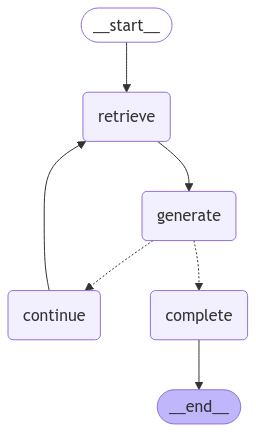

In [5]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
     #This requires some extra dependencies and is optional
    pass

In [35]:
import os
import pandas as pd
import hashlib
import re
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain_core.runnables import RunnablePassthrough
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional, Dict, Literal, Set
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.chat_history import InMemoryChatMessageHistory

# Global variables
retriever = None
mcq_chain = None
question_count = 150

# Chat history tracking
chats_by_session_id = {}
question_history_by_session = {}

def get_chat_history(session_id: str) -> InMemoryChatMessageHistory:
    """Get or create chat history for a session"""
    chat_history = chats_by_session_id.get(session_id)
    if chat_history is None:
        chat_history = InMemoryChatMessageHistory()
        chats_by_session_id[session_id] = chat_history
    return chat_history

def generate_question_hash(question_text):
    """Generate a hash for question deduplication"""
    # Normalize text: remove punctuation, lowercase, remove extra spaces
    normalized = re.sub(r'[^\w\s]', '', question_text.lower()).strip()
    normalized = re.sub(r'\s+', ' ', normalized)
    return hashlib.md5(normalized.encode()).hexdigest()

def check_question_against_history(session_id: str, question_text: str) -> bool:
    """
    Check if a question has been previously generated in this session
    
    Args:
        session_id: The unique session identifier
        question_text: The question text to check
        
    Returns:
        bool: True if the question is new, False if it's a duplicate
    """
    # Initialize question history for this session if it doesn't exist
    if session_id not in question_history_by_session:
        question_history_by_session[session_id] = set()
    
    # Generate hash for quick comparison
    question_hash = generate_question_hash(question_text)
    
    # Check if this question hash exists in history
    if question_hash in question_history_by_session[session_id]:
        return False
    
    # If it's new, add to history and return True
    question_history_by_session[session_id].add(question_hash)
    return True

def extract_questions_from_llm_response(response_text: str) -> Dict[int, str]:
    """
    Parse LLM response to extract questions
    
    Args:
        response_text: The text response from the LLM
        
    Returns:
        Dict[int, str]: Dictionary of question numbers to question text
    """
    lines = response_text.split('\n')
    
    questions = {}
    in_question = False
    current_question = ""
    question_num = None
    
    for line in lines:
        # Skip empty lines
        if not line.strip():
            continue
            
        # Check if this is the answer key section
        if line.strip().lower().startswith("answer key"):
            break
            
        # Detect start of a new question (numbered format)
        if line.strip() and line[0].isdigit() and '. ' in line[:10]:
            # If we were already in a question, save the previous one
            if in_question and current_question:
                questions[question_num] = current_question.strip()
            
            # Start a new question
            parts = line.split('. ', 1)
            question_num = int(parts[0].strip())
            current_question = parts[1] if len(parts) > 1 else ""
            in_question = True
        elif in_question:
            current_question += "\n" + line
    
    # Don't forget the last question
    if in_question and current_question:
        questions[question_num] = current_question.strip()
    
    return questions

def filter_duplicate_questions(session_id: str, llm_response: str) -> str:
    """
    Filter out duplicate questions from LLM response based on session history
    
    Args:
        session_id: The unique session identifier
        llm_response: The full response from the LLM containing questions
        
    Returns:
        str: Filtered response with duplicates removed
    """
    # Extract questions from response
    questions = extract_questions_from_llm_response(llm_response)
    
    # Filter out duplicates
    filtered_questions = {}
    for num, text in questions.items():
        if check_question_against_history(session_id, text):
            filtered_questions[num] = text
    
    # If all questions were duplicates, return empty string
    if not filtered_questions:
        return ""
    
    # Reconstruct the response with only unique questions
    filtered_response = ""
    for num, text in sorted(filtered_questions.items()):
        filtered_response += f"{num}. {text}\n\n"
    
    return filtered_response

# Function to load PDF and create vectorstore
def create_vectorstore_from_pdf(pdf_path):
    # Load PDF
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    
    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    splits = text_splitter.split_documents(docs)
    
    # Initialize HuggingFace embeddings
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    
    # Create FAISS vectorstore
    vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)
    return vectorstore

# Define state structure for the LangGraph
class GraphState(TypedDict):
    question: str
    context: Optional[List[Document]]
    answer: Optional[str]
    batch_num: Optional[int]
    all_questions: Optional[Dict]
    question_hashes: Optional[Set[str]]
    question_types: Optional[Dict]
    next_node: Optional[str]
    session_id: Optional[str]  # Added session_id to track questions by session
    total_questions_generated: Optional[int]  # Track total questions generated to prevent infinite loops

# Function to retrieve context with improved diversity
def retrieve_context(state: GraphState) -> GraphState:
    question = state["question"]
    batch_num = state.get("batch_num", 1)
    
    # Modify retrieval strategy based on batch number to get diverse contexts
    k_docs = 10
    if batch_num > 1:
        # Increase diversity for later batches
        k_docs = 10 + (batch_num * 2)  # Retrieve more docs for later batches
    
    context = retriever.get_relevant_documents(question)
    
    # For subsequent batches, try to retrieve different contexts
    if batch_num > 1 and len(context) > k_docs:
        # Skip some of the most relevant docs that were likely used in earlier batches
        start_idx = min((batch_num - 1) * 3, len(context) - k_docs)
        context = context[start_idx:start_idx + k_docs]
    
    return {
        "question": question, 
        "context": context, 
        "batch_num": batch_num,
        "all_questions": state.get("all_questions", {}),
        "question_hashes": state.get("question_hashes", set()),
        "question_types": state.get("question_types", {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0}),
        "next_node": state.get("next_node"),
        "session_id": state.get("session_id", "default_session"),  # Preserve session ID
        "total_questions_generated": state.get("total_questions_generated", 0)  # Track total questions generated
    }

# Function to check question similarity (internal processing)
def is_similar_question(question_text, existing_hashes):
    # Check exact hash match
    question_hash = generate_question_hash(question_text)
    if question_hash in existing_hashes:
        return True
    
    # Additional similarity checks could be implemented here
    # For example, checking for high word overlap or semantic similarity
    
    return False

# Function to extract and classify question type
def classify_question_type(question_text):
    question_lower = question_text.lower()
    
    # Check for paper reference questions
    if "paper" in question_lower or "author" in question_lower or "introduced" in question_lower:
        return "paper_reference"
    
    # Check for application questions
    elif "apply" in question_lower or "using" in question_lower or "implement" in question_lower or "application" in question_lower:
        return "application"
    
    # Check for analysis questions
    elif "analyze" in question_lower or "compare" in question_lower or "evaluate" in question_lower or "why" in question_lower:
        return "analysis"
    
    # Default to concept questions
    else:
        return "concept"

# Function to parse and deduplicate questions (internal processing)
def parse_and_deduplicate_questions(response_text, existing_hashes, question_types):
    lines = response_text.split('\n')
    
    valid_questions = []
    in_question = False
    current_question = ""
    question_num = None
    
    # Track questions by type to ensure balanced distribution
    type_count = question_types.copy()
    max_paper_reference = 30  # Limit paper reference questions
    
    # Parse the response to extract individual questions
    for line in lines:
        if line.strip().lower().startswith("answer key"):
            break
            
        # Detect start of a new question
        if line.strip() and line[0].isdigit() and '. ' in line[:10]:
            # If we were already in a question, save the previous one
            if in_question and current_question:
                # Check if this is a duplicate question
                if not is_similar_question(current_question, existing_hashes):
                    q_type = classify_question_type(current_question)
                    
                    # Limit paper reference questions
                    if q_type == "paper_reference" and type_count["paper_reference"] >= max_paper_reference:
                        pass  # Skip this question if we have too many paper references
                    else:
                        valid_questions.append((question_num, current_question))
                        existing_hashes.add(generate_question_hash(current_question))
                        type_count[q_type] += 1
            
            # Start a new question
            parts = line.split('. ', 1)
            question_num = int(parts[0].strip())
            current_question = parts[1] if len(parts) > 1 else ""
            in_question = True
        elif in_question:
            current_question += "\n" + line
    
    # Don't forget the last question
    if in_question and current_question:
        if not is_similar_question(current_question, existing_hashes):
            q_type = classify_question_type(current_question)
            if not (q_type == "paper_reference" and type_count["paper_reference"] >= max_paper_reference):
                valid_questions.append((question_num, current_question))
                existing_hashes.add(generate_question_hash(current_question))
                type_count[q_type] += 1
    
    # Reconstruct the response with only valid questions
    deduped_response = ""
    for num, q_text in valid_questions:
        deduped_response += f"{num}. {q_text}\n\n"
    
    return deduped_response, type_count

# Function to generate MCQs with improved quality controls and chat history check
def generate_mcqs(state: GraphState) -> GraphState:
    question = state["question"]
    context = state["context"]
    batch_num = state["batch_num"]
    all_questions = state.get("all_questions", {})
    question_hashes = state.get("question_hashes", set())
    question_types = state.get("question_types", {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0})
    session_id = state.get("session_id", "default_session")  # Get session ID from state
    total_questions_generated = state.get("total_questions_generated", 0)
    
    # We'll generate in smaller batches to ensure diversity and avoid repetition
    batch_size = 30  # Generate 30 questions per batch
    
    # Safety check: if we've already gone through 20 batches, complete the process
    # This prevents infinite loops
    if batch_num > 20:
        final_answer = compile_batches(all_questions)
        return {
            "question": question, 
            "context": context, 
            "answer": final_answer,
            "batch_num": batch_num,
            "all_questions": all_questions,
            "question_hashes": question_hashes,
            "question_types": question_types,
            "next_node": "complete",
            "session_id": session_id,
            "total_questions_generated": total_questions_generated
        }
    
    # Adjust prompt based on question types we need more of
    prompt_focus = "conceptual understanding and application"
    if question_types['application'] < question_types['concept']:
        prompt_focus = "practical applications and implementations"
    elif question_types['analysis'] < question_types['application']:
        prompt_focus = "critical analysis and evaluation"
    elif question_types['paper_reference'] < 25:  # Ensure some paper references, but not too many
        prompt_focus = "important research contributions, but focus on the concepts not just the authors"
    
    # Invoke the chain with adjusted parameters
    response = mcq_chain.invoke({
        "input": question,
        "context": context,
        "num_questions": batch_size,
        "batch_num": batch_num,
        "existing_questions": all_questions,
        "focus_area": prompt_focus
    })
    
    # Handle AIMessage object by extracting the content
    if hasattr(response, 'content'):
        result = response.content
    else:
        result = str(response)
    
    # Filter out questions that already exist in chat history
    filtered_result = filter_duplicate_questions(session_id, result)
    
    # If all questions were duplicates, retry with a different prompt
    retry_count = 0
    while not filtered_result and retry_count < 3:
        retry_count += 1
        # Modify prompt to get different questions
        modified_focus = f"{prompt_focus} with completely different examples and scenarios (attempt {retry_count})"
        
        response = mcq_chain.invoke({
            "input": question,
            "context": context,
            "num_questions": batch_size,
            "batch_num": batch_num + retry_count,  # Increment batch number to get different context
            "existing_questions": all_questions,
            "focus_area": modified_focus
        })
        
        if hasattr(response, 'content'):
            result = response.content
        else:
            result = str(response)
            
        filtered_result = filter_duplicate_questions(session_id, result)
    
    # Parse and deduplicate questions (still needed for internal tracking)
    deduped_result, updated_question_types = parse_and_deduplicate_questions(
        filtered_result, 
        question_hashes,
        question_types
    )
    
    # Count new valid questions from this batch
    new_questions_count = sum(updated_question_types.values()) - sum(question_types.values())
    total_questions_generated += new_questions_count
    
    # Only add batch if it contains questions after deduplication
    if deduped_result.strip():
        all_questions[f"batch_{batch_num}"] = deduped_result
    
    # Determine if we need more batches based on total question count target
    # or if we're not making progress (no new questions in this batch)
    if total_questions_generated >= question_count or new_questions_count == 0:
        next_node = "complete"
    else:
        next_node = "continue"
    
    # If we're done, compile the final result
    final_answer = None
    if next_node == "complete":
        final_answer = compile_batches(all_questions)
    
    return {
        "question": question, 
        "context": context, 
        "answer": final_answer,
        "batch_num": batch_num + 1,
        "all_questions": all_questions,
        "question_hashes": question_hashes,
        "question_types": updated_question_types,
        "next_node": next_node,
        "session_id": session_id,
        "total_questions_generated": total_questions_generated
    }

# Router function to determine next step
def router(state: GraphState) -> Literal["continue", "complete"]:
    return state["next_node"]

# Function to compile all batches into a single result with improved formatting
def compile_batches(all_questions):
    final_result = "# Multiple Choice Questions\n\n"
    answer_key = "\n\n# Answer Key\n\n"
    question_num = 1
    
    # Track questions by type for summary statistics
    question_type_counts = {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0}
    
    for batch_key in sorted(all_questions.keys()):
        batch_content = all_questions[batch_key]
        
        # Extract questions and answer key using simple parsing
        lines = batch_content.split('\n')
        
        in_questions = True
        current_question = ""
        
        for line in lines:
            if line.strip().lower().startswith("answer key"):
                in_questions = False
                continue
            
            if in_questions:
                # Check if line starts with a question number
                if line.strip() and line[0].isdigit() and '. ' in line[:10]:
                    # If we were collecting a question, save it first
                    if current_question:
                        q_type = classify_question_type(current_question)
                        question_type_counts[q_type] += 1
                        
                    # Replace the question number with our sequential number
                    parts = line.split('. ', 1)
                    if len(parts) > 1:
                        current_question = parts[1]
                        final_result += f"{question_num}. {current_question}\n"
                        question_num += 1
                else:
                    final_result += line + "\n"
            else:
                # In answer key section
                if line.strip() and line[0].isdigit() and '.'in line[:5]:
                    # Extract and update answer key
                    parts = line.split('.', 1)
                    if len(parts) > 1:
                        original_q_num = int(parts[0].strip())
                        # Calculate the adjusted question number
                        batch_index = int(batch_key.split('_')[1]) - 1
                        adjusted_q_num = batch_index * 30 + original_q_num
                        answer_key += f"{adjusted_q_num}.{parts[1]}\n"
    
    # Add summary statistics
    summary = "\n\n# Question Distribution\n\n"
    summary += f"- Concept Questions: {question_type_counts['concept']}\n"
    summary += f"- Application Questions: {question_type_counts['application']}\n"
    summary += f"- Analysis Questions: {question_type_counts['analysis']}\n"
    summary += f"- Paper Reference Questions: {question_type_counts['paper_reference']}\n"
    
    return final_result + answer_key + summary

# Function to continue processing
def continue_processing(state: GraphState) -> GraphState:
    # Reset next_node to None to avoid infinite loops
    state["next_node"] = None
    return state

# Function to complete processing
def complete_processing(state: GraphState) -> GraphState:
    return state

# Function to set up the MCQ generation pipeline
def setup_mcq_generator(pdf_path, num_questions=150, api_key=None):
    # Set API key if provided
    if api_key:
        os.environ["GROQ_API_KEY"] = api_key
    
    # Set question count in global variable
    global question_count
    question_count = num_questions
    
    # Initialize Groq LLM with Qwen model
    llm = ChatGroq(
        model="qwen-2.5-32b",
        temperature=0.7,  # Add some randomness to avoid repetitive questions
        api_key="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"
    )
    
    # Create vectorstore and retriever
    vectorstore = create_vectorstore_from_pdf(pdf_path)
    global retriever
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 10}  # Increase retrieval to get more diverse content
    )
    
    # Create improved MCQ generation prompt
    system_template = """
    You are an expert in designing educational multiple-choice questions for ML/AI topics that assess deep understanding and critical thinking. Using the retrieved context provided below, generate {num_questions} high-quality, challenging multiple-choice questions that cover a range of topics within the material.

    This is batch #{batch_num} of questions. To ensure high quality:

    1. IMPORTANT: Focus especially on {focus_area} questions for this batch.
    2. Questions must be diverse in both content and question types - include a mix of:
       - Conceptual understanding (core ideas, definitions, theory)
       - Practical applications (how concepts are used in real systems)
       - Critical analysis (comparing approaches, evaluating trade-offs)
       - Research context (limited to key contributions, not just who wrote what paper)
       - Dont Ask any question about any refernce like [interger no] and dont ask adout information about paper like 8] Yonghui Wu, Mike Schuster, Zhifeng Chen, Quoc V Le, Mohammad Norouzi, Wolfgang
     Macherey, Maxim Krikun, Yuan Cao, Qin Gao, Klaus Macherey, et al. Google's neural machine
     translation system: Bridging the gap between human and machine translation. arXiv preprint
     arXiv:1609.08144, 2016
    3. Question structure requirements:
       • The question prompt should be clear and test understanding rather than memorization
       • There must be exactly four answer options labeled A, B, C, and D
       • Only one option is correct, with three plausible distractors
       • Each question must test a DIFFERENT concept or application
       • AVOID questions that simply ask "which paper introduced X" without testing understanding
       • Write questions that a human with domain understanding could reasonably answer
       • NEVER ask questions that require memorizing arbitrary details like dates or exact author names
    
    4. Quality control:
       • NO DUPLICATES - check that each question is unique  
       • Questions should be useful for learning, not trivial
       • For paper references, focus on the contributions and ideas, not just matching authors to topics
       • If citing papers, ensure citations are accurate based on the context

    After presenting all the questions with their corresponding options, include a detailed answer key that clearly indicates the correct answer for each question.

    Retrieved context:
    {context}
    """
    
    human_template = "This is batch #{batch_num}. Create {num_questions} unique multiple-choice questions from this content focusing on {focus_area}."
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_template),
        ("human", human_template)
    ])
    
    # Create chain for MCQ generation
    global mcq_chain
    mcq_chain = prompt | llm
    
    # Create the graph
    workflow = StateGraph(GraphState)
    
    # Add nodes
    workflow.add_node("retrieve", retrieve_context)
    workflow.add_node("generate", generate_mcqs)
    workflow.add_node("continue", continue_processing)
    workflow.add_node("complete", complete_processing)
    
    # Define edges with conditional routing
    workflow.add_edge(START, "retrieve")
    workflow.add_edge("retrieve", "generate")
    workflow.add_conditional_edges(
        "generate",
        router,
        {
            "continue": "continue",
            "complete": "complete"
        }
    )
    workflow.add_edge("continue", "retrieve")
    workflow.add_edge("complete", END)
    
    # Compile the graph - removed the recursion_limit parameter which was causing the error
    app = workflow.compile()
    
    return app

# Function to run MCQ generator
def run_mcq_generator(app, session_id="default_session", question="Generate diverse multiple-choice questions that test conceptual understanding from this document"):
    result = app.invoke({
        "question": question,
        "batch_num": 1,
        "all_questions": {},
        "question_hashes": set(),
        "question_types": {'concept': 0, 'application': 0, 'analysis': 0, 'paper_reference': 0},
        "next_node": None,
        "session_id": session_id,  # Include session ID in the state
        "total_questions_generated": 0  # Initialize counter for generated questions
    })
    return result["answer"]

# Function to clear question history for a session
def clear_session_history(session_id):
    """Clear the question history for a specific session"""
    if session_id in question_history_by_session:
        question_history_by_session[session_id] = set()
        return True
    return False

# Example usage
if __name__ == "__main__":
    pdf_path = r"C:\Users\Sumit\Downloads\attention.pdf"  # Replace with your PDF file path
    app = setup_mcq_generator(pdf_path, num_questions=150)
    
    # Generate MCQs for a specific session
    session_id = "user_123"
    mcqs = run_mcq_generator(app, session_id=session_id)
    print(mcqs)
    
    # If you run it again with the same session_id, it will avoid generating the same questions
    more_mcqs = run_mcq_generator(app, session_id=session_id, 
                                  question="Generate more multiple-choice questions about advanced concepts")
    print(more_mcqs)

# Multiple Choice Questions

1. B) Transformer


2. B) Reading comprehension


3. D) It enables parallel computation of dependencies across all positions


4. B) Attention between different positions within a single sequence


5. B) To normalize the attention weights


6. C) Self-Attention


7. B) It enables parallel computation of dependencies across all positions


8. B) To enable the model to focus on different parts of the input sequence simultaneously


9. **Question:** Which task is NOT typically addressed by self-attention mechanisms in the Transformer model?
    - A) Reading comprehension
    - B) Image classification
    - C) Abstractive summarization
    - D) Textual entailment
    **Answer:** B) Image classification


10. **Question:** In the Transformer model, what is the role of the Multi-Head Attention mechanism?
    - A) To reduce the number of parameters
    - B) To enable the model to focus on different parts of the input sequence simultaneously
    - C) To increase th